In [1]:
import sys
# change the system path to the partent directory of the current file, so that we can import the QNN framework
sys.path.append("..")

In [2]:
import matplotlib.pyplot as plt
import pennylane as qp
from pennylane import numpy as np

import torch

from importlib import reload

In [3]:
import circuits
reload(circuits)

<module 'circuits' from '/home/tardant/Bureau/pennylane/Circuits_training/notebooks/../circuits.py'>

Shape of the weight tensor: torch.Size([2, 4, 2])


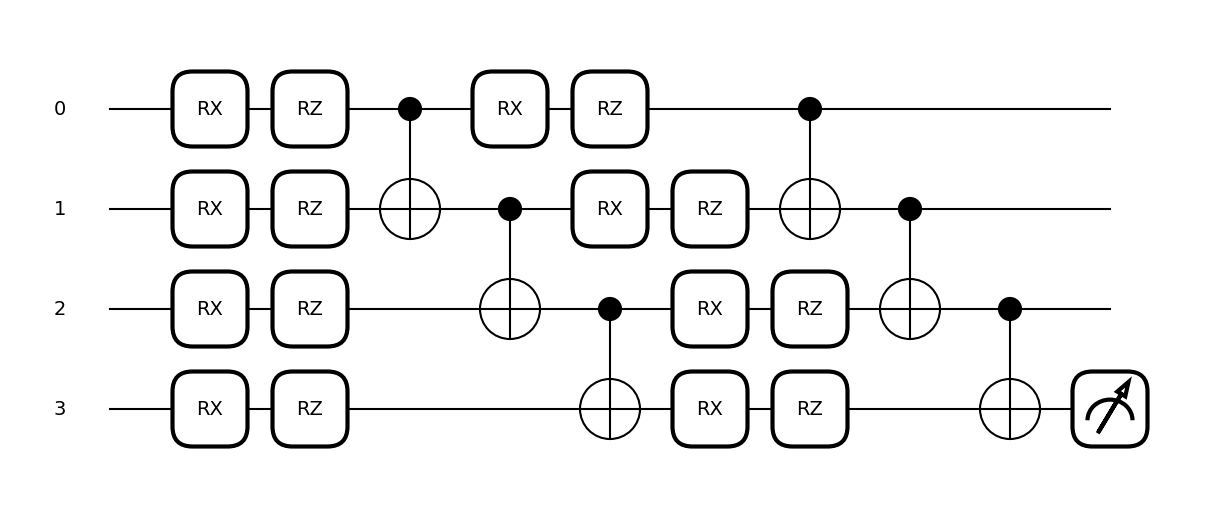

In [13]:
n_qubits = 4

dev = qp.device("default.qubit", wires=n_qubits)

num = 2

circuit_to_call = circuits.circuit_set(num=num)  # choose the circuit to call

@qp.qnode(dev, interface="torch")
def circuit_set(weights):

    circuit_to_call(weights, wires =list(range(n_qubits)))

    return qp.expval(qp.PauliZ(wires=3))

layers = 2  # number of layers in the circuit

shape = circuits.weight_tensor_shape(num, n_qubits, layers)  # get the shape of the weight tensor for the chosen circuit

weights = (
    2 * np.pi * torch.rand(shape, dtype=torch.float32, requires_grad=True)
)  # some random initial weights

x = np.linspace(-6, 6, 70, requires_grad=False)
x = torch.tensor(x, dtype=torch.float32, requires_grad=False)
print(f"Shape of the weight tensor: {weights.shape}")
random_quantum_model_y = circuit_set(weights)

qp.draw_mpl(circuit_set, level="device")(weights)
plt.show()

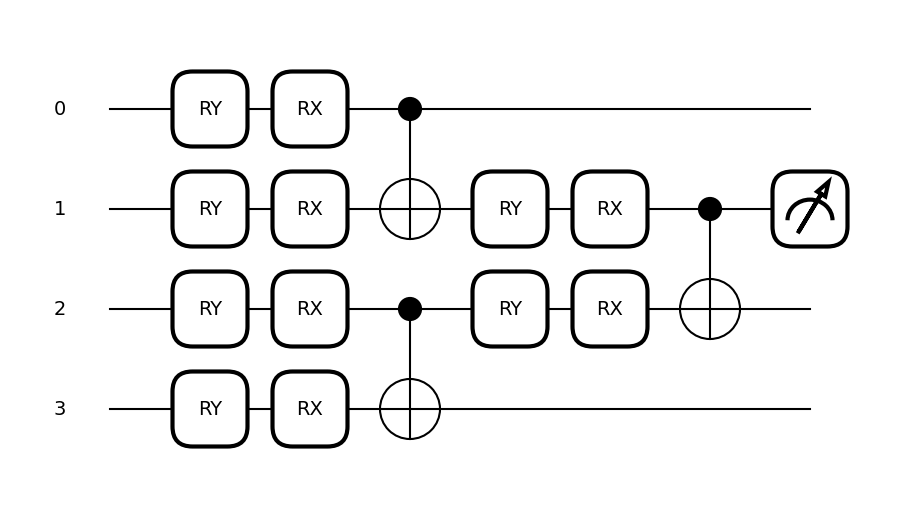

In [7]:
n_qubits = 4

dev = qp.device("default.qubit", wires=n_qubits)

circuit_to_call = circuits.circuit_set(num=32)

@qp.qnode(dev, interface="torch")
def circuit_two_rotations_brickwall(weights):

    circuit_to_call(weights, wires =list(range(n_qubits)))

    return qp.expval(qp.PauliZ(wires=1))

layers = 2  # number of layers in the circuit

r = 1  # number of times the encoding gets repeated (here equal to the number of layers)
weights = (
    2 * np.pi * torch.rand((layers, n_qubits , 2), dtype=torch.float32, requires_grad=True)
)  # some random initial weights

x = np.linspace(-6, 6, 70, requires_grad=False)
x = torch.tensor(x, dtype=torch.float32, requires_grad=False)
random_quantum_model_y = circuit_two_rotations_brickwall(weights)

qp.draw_mpl(circuit_two_rotations_brickwall, level="device")(weights)
plt.show()

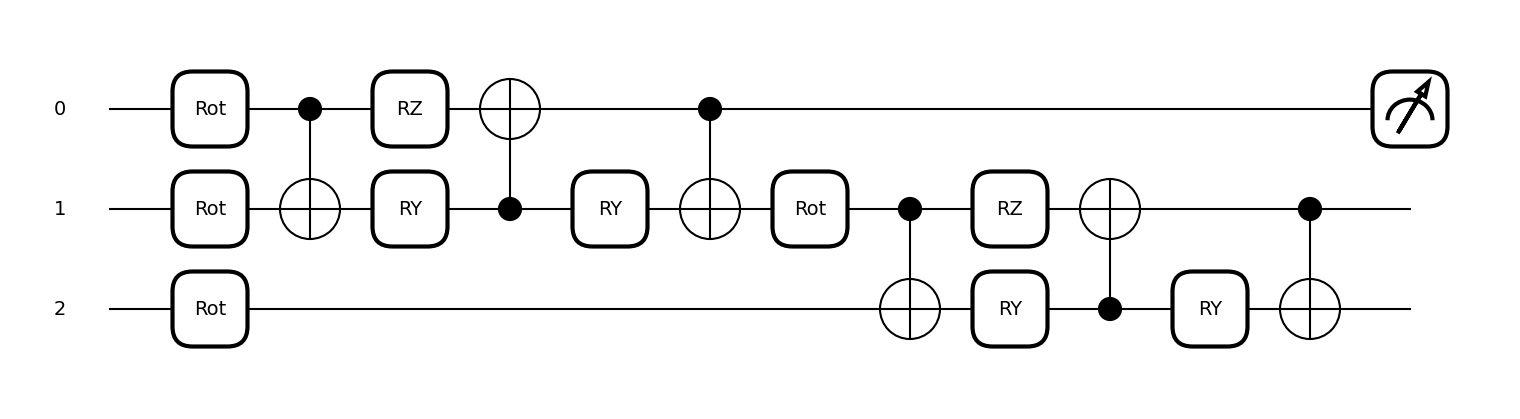

In [8]:
n_qubits = 3

dev = qp.device("default.qubit", wires=n_qubits)

circuit_to_call = circuits.circuit_set(num=31)

@qp.qnode(dev, interface="torch")
def circuit_perfect_SU4(weights):

    circuit_to_call(weights, wires =list(range(n_qubits)))

    return qp.expval(qp.PauliZ(wires=0))

layers = 2  # number of layers in the circuit

r = 1  # number of times the encoding gets repeated (here equal to the number of layers)
weights = (
    2 * np.pi * torch.rand((layers, n_qubits//2 , 3, 3), dtype=torch.float32, requires_grad=True)
)  # some random initial weights

x = np.linspace(-6, 6, 70, requires_grad=False)
x = torch.tensor(x, dtype=torch.float32, requires_grad=False)
random_quantum_model_y = circuit_perfect_SU4(weights)

qp.draw_mpl(circuit_perfect_SU4, level="device")(weights)
plt.show()